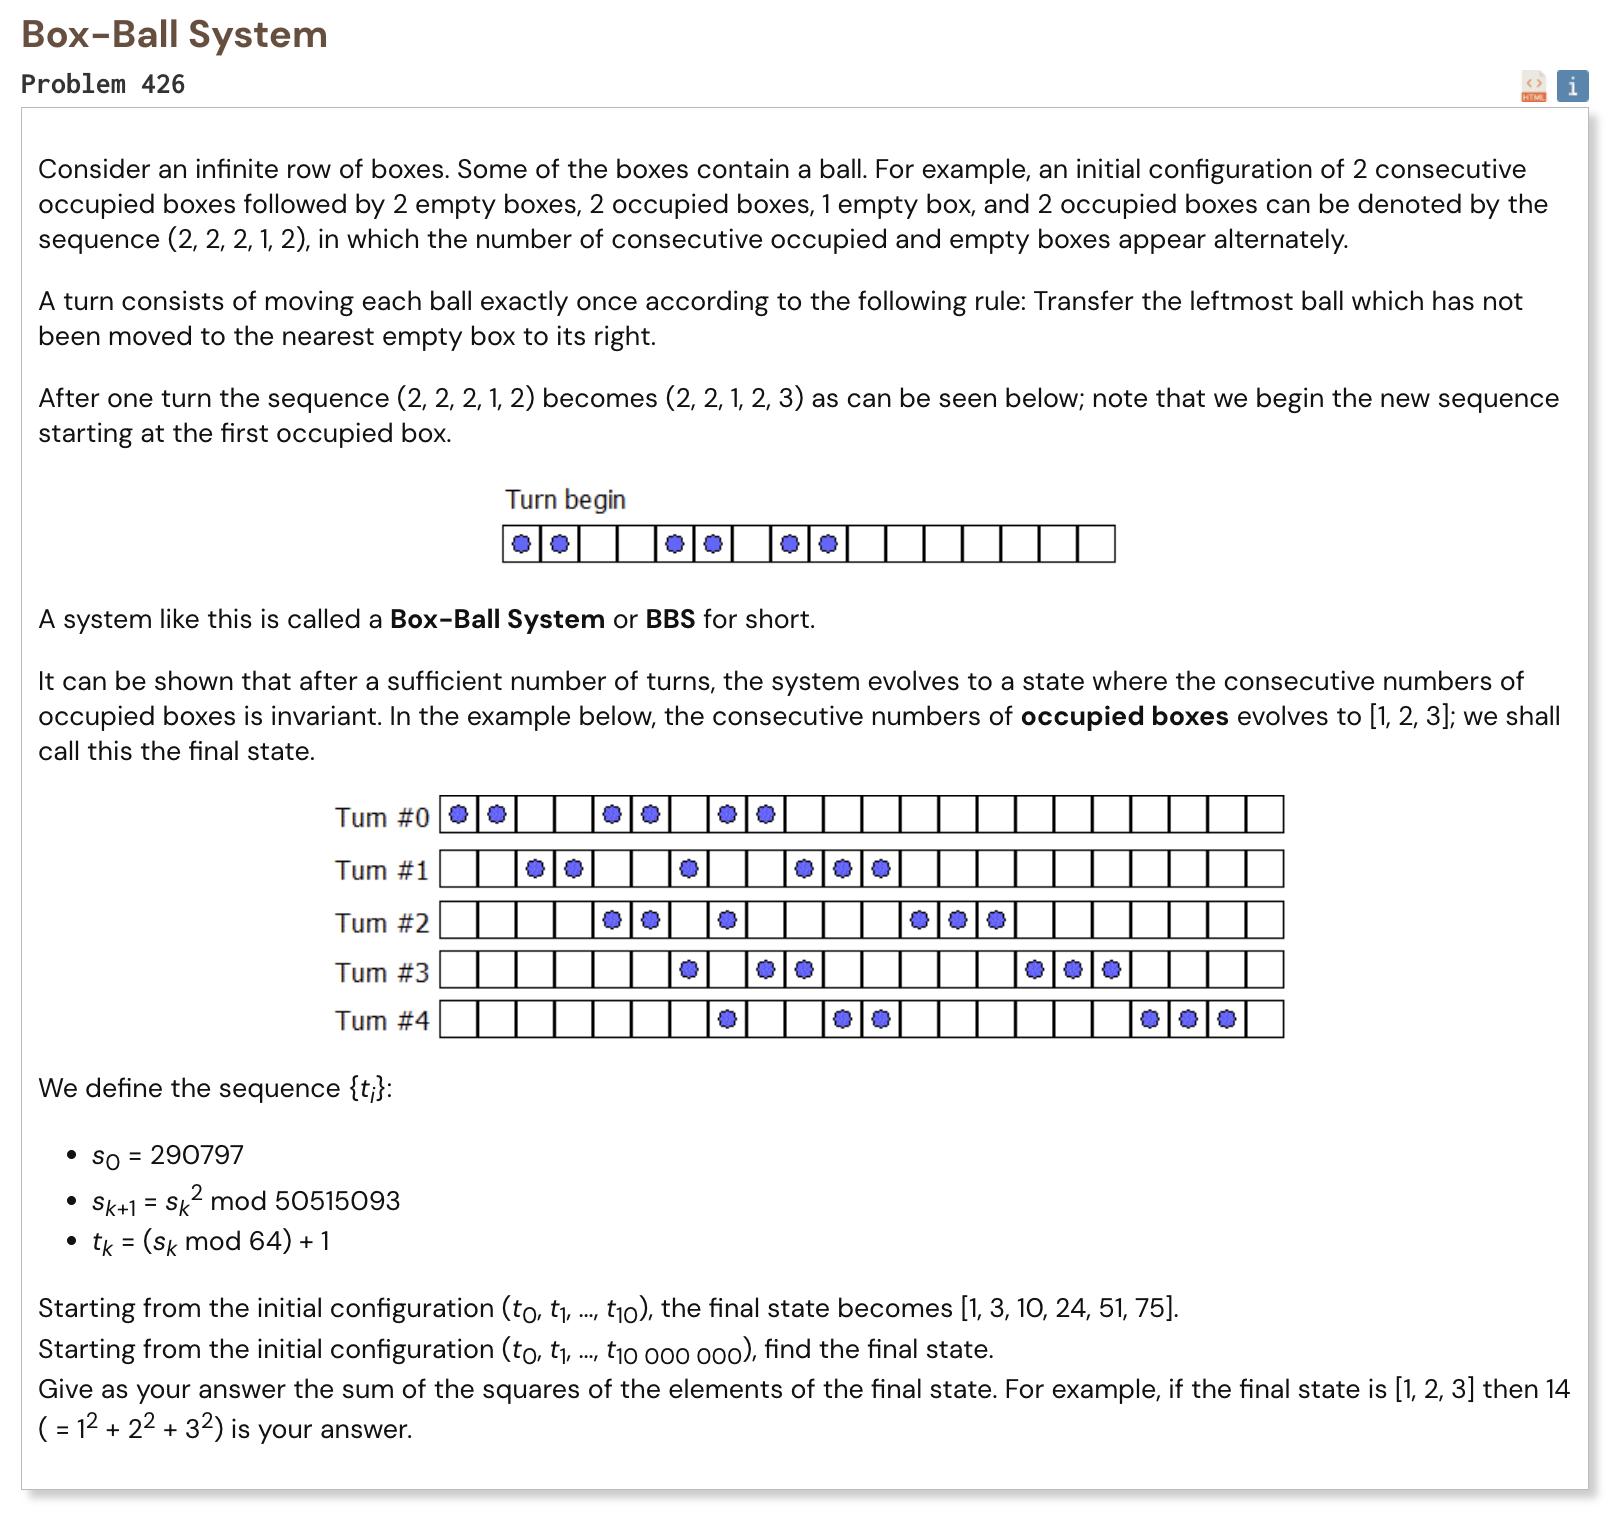

## Initial approach

-   represent occupied boxes as ones and empty boxes as zeros
-   instead of simulating millions of BBS turns, repeatedly think of adjacent one zero pairs being removed
-   each removed pair belongs to a certain removal round, and these rounds describe the final stable groups
-   process whole runs at once because every run has at most 64 boxes
-   keep a compressed stack so individual boxes never need to be stored
-   use a difference list to count many consecutive removal rounds efficiently
-   rebuild the final group sizes from these counts and add their squares

In [1]:
LIMIT = 10_000_000
MOD = 50515093


def generate_t(n):
    s = 290797

    for _ in range(n + 1):
        yield (s % 64) + 1
        s = (s * s) % MOD


def solve(n):
    stack = []
    diff = [0, 0]

    def add_range(low, high):
        if high + 2 > len(diff):
            diff.extend([0] * (high + 2 - len(diff)))

        diff[low] += 1
        diff[high + 1] -= 1

    def remove_boxes(amount):
        while amount > 0 and stack:
            length, level = stack[-1]
            used = min(amount, length)

            low = level + 1
            high = level + used

            add_range(low, high)

            amount -= used

            if used == length:
                stack.pop()

                if stack:
                    old_length, old_level = stack[-1]
                    stack[-1] = (
                        old_length,
                        max(old_level, high)
                    )
            else:
                stack[-1] = (
                    length - used,
                    high
                )

    for i, length in enumerate(generate_t(n)):
        if i % 2 == 0:
            stack.append((length, 0))
        else:
            remove_boxes(length)

    while stack:
        remove_boxes(stack[-1][0])

    counts = []
    current = 0

    for level in range(1, len(diff) - 1):
        current += diff[level]
        counts.append(current)

    while counts and counts[-1] == 0:
        counts.pop()

    result = 0

    for size in range(1, len(counts) + 1):
        next_count = counts[size] if size < len(counts) else 0
        number_of_groups = counts[size - 1] - next_count
        result += number_of_groups * size * size

    return result

In [2]:
%%time
assert solve(10) == 8912
result = solve(LIMIT)
print("Result:", result)

Result: 31591886008
CPU times: user 7.82 s, sys: 77.8 ms, total: 7.9 s
Wall time: 7.99 s
